# Week 11 · A VAE you can see

**Mode: tutorial · Monday + Tuesday · three implementation exercises**

You have already done the derivations. Here, the objective is to watch them
become a working model: **image → distribution → sampled point → reconstructed image**.

Keep this notebook as the baseline. Work in **`w11_minimal_vae_mnist_solved.ipynb`**,
which starts as an exact copy, not a pre-filled answer key.

| Session | Route | Stop condition |
|---|---|---|
| Monday · 60–75 min | See the data → encoder/decoder → TODOs 1–2 → one training step | Shapes and loss checks pass; gradients reach both networks |
| Tuesday · 60–75 min | Short training run → loss curves → reconstructions → TODO 3 → interpretation | Inspect the results and write three short observations |

These are timeboxes, not deadlines. If setup or debugging consumes the session,
carry the remaining section forward. No new proofs or lectures are required.

**Provided:** data loading, network architecture, optimizer, training loop, and plots.
**You implement:** sampling, the loss, and a one-coordinate latent traversal.
Exercise cells deliberately stop with a clear error until you fill them in.

References when needed: [VAE foundations](../notes/w11_cs236_vae.md) and
[your ELBO derivation](../notes/w11_elbo_derivation.md).


## Monday · 1. Set the scale

- Each grayscale image has $D=28\times28=784$ observed coordinates, scaled to $[0,1]$.
- Each latent point has **$d=2$** coordinates. This makes visualization easy;
  it is a deliberately severe compression bottleneck, not a recipe for sharp images.
- $p(z)=\mathcal N(0,I_2)$ and
  $q_\phi(z\mid x)=\mathcal N(\mu_\phi(x),\operatorname{diag}(\sigma_\phi^2(x)))$.
- The decoder predicts a mean image for a **fixed-variance Gaussian likelihood**.
  We keep the model you derived, rather than switching to a Bernoulli/BCE objective.
- The decoder mean is bounded to $[0,1]$ by a sigmoid. That does **not** make the
  likelihood Bernoulli: the observation model remains Gaussian and its samples
  can lie outside $[0,1]$.

Start with 10,000 training images, 1,000 held-out images, and five epochs on CPU.
This is a learning run, not a benchmark. Labels are used **only to color plots**.


In [1]:
from pathlib import Path
import gzip
import hashlib
import os
import struct
import time
import urllib.request

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Works from the repository root or notebooks/; all generated data stay ignored.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'pyproject.toml').exists() and (p / 'notebooks').is_dir())
CACHE = ROOT / 'scratch' / 'w11_vae'
CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(CACHE / 'matplotlib'))
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyBboxPatch

config = dict(seed=11, n_train=10_000, n_test=1_000, batch_size=128,
              latent_dim=2, hidden_dim=128, epochs=5, learning_rate=1e-3,
              tau_squared=0.1)
assert config['tau_squared'] > 0 and config['latent_dim'] == 2
SEED = config['seed']
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
device = torch.device('cpu')  # Consistent, modest default; no GPU required.
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 11,
                     'font.size': 10, 'figure.facecolor': '#fafaf8'})
COLORS = {'encoder': '#157a8c', 'latent': '#a05bb5', 'decoder': '#dd8844'}
print(f"Device: {device} | image D=784 → latent d=2 | cache: {CACHE}")


Device: cpu | image D=784 → latent d=2 | cache: /Users/juanpineros/juancopi81/diffusion-research-curriculum/scratch/w11_vae


### Provided infrastructure: real MNIST, no extra dependency

This helper downloads the four MNIST gzip files (~12 MB total), checks their
published checksums, reads the IDX headers, and caches them under ignored
`scratch/w11_vae/mnist/`. Subsequent runs reuse the cache. The first run needs
internet access; a download failure is a setup issue, not a VAE exercise.

The mirror and checksums come from the
[PyTorch MNIST dataset implementation](https://github.com/pytorch/vision/blob/main/torchvision/datasets/mnist.py).
MNIST consists of handwritten digit images; the training and test files are
separate. We select seeded subsets without replacement, with no test images
used for optimization. **You do not need to study the file parser.**


In [2]:
MNIST_URL = 'https://ossci-datasets.s3.amazonaws.com/mnist/'
RESOURCES = {
    'train-images-idx3-ubyte.gz': 'f68b3c2dcbeaaa9fbdd348bbdeb94873',
    'train-labels-idx1-ubyte.gz': 'd53e105ee54ea40749a09fcbcd1e9432',
    't10k-images-idx3-ubyte.gz': '9fb629c4189551a2d022fa330f9573f3',
    't10k-labels-idx1-ubyte.gz': 'ec29112dd5afa0611ce80d1b7f02629c',
}

def read_mnist(filename: str) -> np.ndarray:
    """Download, check, and decode one MNIST IDX file."""
    folder = CACHE / 'mnist'
    folder.mkdir(exist_ok=True)
    target = folder / filename
    if not target.exists():
        print(f'Downloading {filename} …')
        try:
            with urllib.request.urlopen(MNIST_URL + filename, timeout=60) as response:
                payload = response.read()
        except Exception as exc:
            raise RuntimeError('MNIST download failed. Check internet access and rerun this cell.') from exc
        if hashlib.md5(payload).hexdigest() != RESOURCES[filename]:
            raise ValueError(f'Checksum mismatch for downloaded {filename}')
        target.write_bytes(payload)
    payload = target.read_bytes()
    if hashlib.md5(payload).hexdigest() != RESOURCES[filename]:
        raise ValueError(f'Corrupt cache file: {target}. Remove just this file and retry.')
    raw = gzip.decompress(payload)
    magic, count = struct.unpack('>II', raw[:8])
    if magic == 2051:
        rows, cols = struct.unpack('>II', raw[8:16])
        assert (rows, cols) == (28, 28)
        return np.frombuffer(raw, dtype=np.uint8, offset=16).reshape(count, rows * cols).copy()
    assert magic == 2049, f'Unexpected IDX magic: {magic}'
    return np.frombuffer(raw, dtype=np.uint8, offset=8).reshape(count).copy()

def load_subset(prefix: str, count: int, seed: int):
    images = read_mnist(f'{prefix}-images-idx3-ubyte.gz')
    labels = read_mnist(f'{prefix}-labels-idx1-ubyte.gz')
    assert len(images) == len(labels) and 0 < count <= len(images)
    indices = np.random.default_rng(seed).choice(len(images), count, replace=False)
    return torch.from_numpy(images[indices]).float() / 255, torch.from_numpy(labels[indices]).long()

train_x, train_y = load_subset('train', config['n_train'], SEED)
test_x, test_y = load_subset('t10k', config['n_test'], SEED + 1)
def make_train_loader():
    return DataLoader(TensorDataset(train_x), batch_size=config['batch_size'],
                      shuffle=True, generator=torch.Generator().manual_seed(SEED))

assert train_x.shape == (config['n_train'], 784)
assert test_x.shape == (config['n_test'], 784)
assert 0 <= train_x.min() and train_x.max() <= 1
print(f'Train: {tuple(train_x.shape)} | held out: {tuple(test_x.shape)}')


Train: (10000, 784) | held out: (1000, 784)


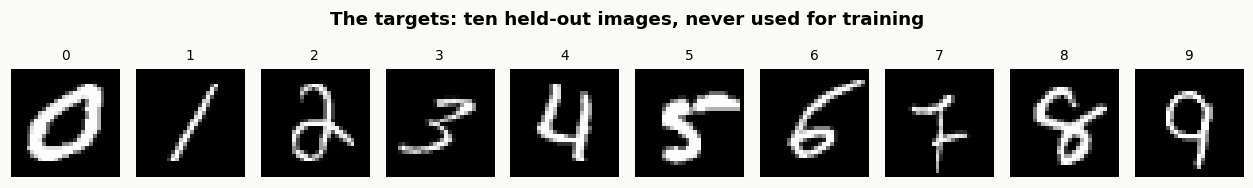

In [3]:
def image_grid(images, rows=1, cols=10, title='', labels=None):
    """Display decoder means or input images on a common grayscale scale."""
    images = torch.as_tensor(images).detach().cpu().reshape(-1, 28, 28)
    assert len(images) >= rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.15, rows * 1.3 + 0.5), squeeze=False)
    for k, ax in enumerate(axes.flat):
        ax.imshow(images[k], cmap='gray', vmin=0, vmax=1)
        ax.set_axis_off()
        if labels is not None:
            ax.set_title(str(labels[k]), fontsize=9)
    fig.suptitle(title, fontweight='bold')
    fig.tight_layout()
    plt.show()

# One representative of each digit, held fixed for comparisons throughout.
example_indices = torch.tensor([torch.where(test_y == digit)[0][0].item() for digit in range(10)])
examples = test_x[example_indices]
image_grid(examples, title='The targets: ten held-out images, never used for training', labels=range(10))


## Monday · 2. Follow one image through the model

The encoder does not output a digit label or one definitive latent point. It
outputs **two vectors defining a distribution for each image**. Sampling then
selects a point from that distribution. The decoder maps that point to 784 mean
pixel values.

| Object | Batch shape | Meaning |
|---|---|---|
| `x` | `(B, 784)` | Flattened observed images |
| `mu`, `logvar` | `(B, 2)` each | Conditional Gaussian parameters |
| `std`, `epsilon`, `z` | `(B, 2)` each | Standard deviation, base noise, sampled latent |
| `decoder_mean` | `(B, 784)` | Gaussian mean images, **not** observation samples |

The shared hidden layer feeds two encoder heads. The decoder is another small
network. Read the architecture; implementing its boilerplate is not an exercise.


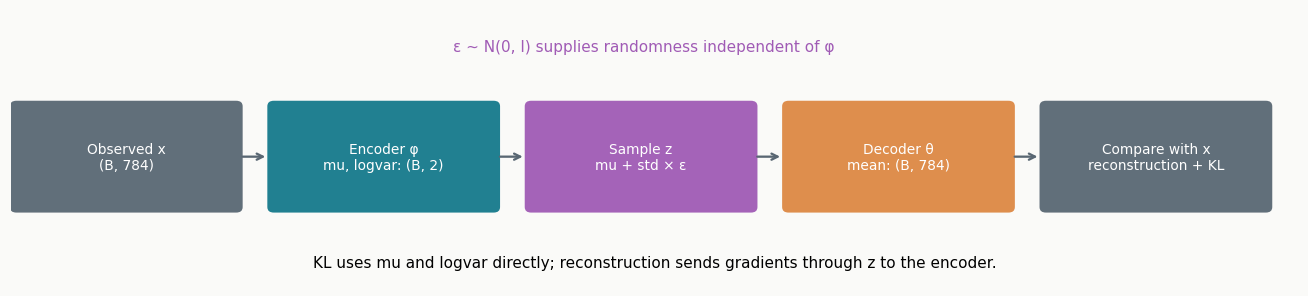

In [4]:
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.set(xlim=(0, 12), ylim=(0, 3))
ax.axis('off')
boxes = [(0.05, 'Observed x\n(B, 784)', '#596773'),
         (2.45, 'Encoder φ\nmu, logvar: (B, 2)', COLORS['encoder']),
         (4.85, 'Sample z\nmu + std × ε', COLORS['latent']),
         (7.25, 'Decoder θ\nmean: (B, 784)', COLORS['decoder']),
         (9.65, 'Compare with x\nreconstruction + KL', '#596773')]
for left, text, color in boxes:
    ax.add_patch(FancyBboxPatch((left, 0.85), 2.05, 1.1, boxstyle='round,pad=0.06',
                               facecolor=color, edgecolor='none', alpha=0.95))
    ax.text(left + 1.025, 1.4, text, ha='center', va='center', color='white', fontsize=9)
    if left < 9:
        ax.annotate('', xy=(left + 2.35, 1.4), xytext=(left + 2.08, 1.4),
                    arrowprops=dict(arrowstyle='->', color='#596773', lw=1.5))
ax.text(5.9, 2.55, 'ε ~ N(0, I) supplies randomness independent of φ', ha='center', color=COLORS['latent'])
ax.text(6, 0.2, 'KL uses mu and logvar directly; reconstruction sends gradients through z to the encoder.',
        ha='center', fontsize=10)
fig.tight_layout()
plt.show()


### TODO 1 of 3 · Reparameterize (about 5–10 min)

Fill just the two missing lines. For a fixed image:

$$
\epsilon\sim\mathcal N(0,I_2),\qquad
z=\mu_\phi(x)+\exp\!\left(\tfrac12\log\sigma_\phi^2(x)\right)\odot\epsilon.
$$

The random noise is provided. Use elementwise tensor operations; do not convert
to NumPy or detach tensors here, because the encoder needs the gradient path.


In [5]:
def reparameterize(mu: torch.Tensor, logvar: torch.Tensor,
                 epsilon: torch.Tensor | None = None) -> torch.Tensor:
    """Sample a diagonal Gaussian with a differentiable parameter path."""
    if epsilon is None:
        epsilon = torch.randn_like(mu)
    assert mu.shape == logvar.shape == epsilon.shape
    std = (0.5 * logvar).exp()
    return mu + std * epsilon


In [6]:
mu_check = torch.tensor([[1., -1.]])
logvar_check = torch.log(torch.tensor([[4., 0.25]]))
epsilon_check = torch.tensor([[0.5, -2.]])
assert torch.allclose(reparameterize(mu_check, logvar_check, epsilon_check), torch.tensor([[2., -2.]]))
assert torch.allclose(reparameterize(mu_check, logvar_check, torch.zeros_like(mu_check)), mu_check)

# Empirical check: sampling changes the mechanism, not the desired distribution.
with torch.random.fork_rng():
    torch.manual_seed(SEED)
    draws = reparameterize(mu_check.expand(20_000, -1), logvar_check.expand(20_000, -1))
assert torch.allclose(draws.mean(0), mu_check[0], atol=0.05)
assert torch.allclose(draws.var(0), logvar_check.exp()[0], atol=0.12)
# Check the reconstruction's path through z, independently of the analytic KL.
mu_grad = mu_check.clone().requires_grad_()
logvar_grad = logvar_check.clone().requires_grad_()
grad_mu, grad_logvar = torch.autograd.grad(
    reparameterize(mu_grad, logvar_grad, epsilon_check).sum(), (mu_grad, logvar_grad))
assert torch.allclose(grad_mu, torch.ones_like(mu_grad))
assert torch.allclose(grad_logvar, 0.5 * (0.5 * logvar_check).exp() * epsilon_check)
print('Sampling checks passed: shape, mean, variance, and differentiable parameter path.')


Sampling checks passed: shape, mean, variance, and differentiable parameter path.


In [7]:
class MinimalVAE(nn.Module):
    """Encode a Gaussian distribution and decode a mean image."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, config['hidden_dim']), nn.ReLU())
        self.mu_head = nn.Linear(config['hidden_dim'], config['latent_dim'])
        self.logvar_head = nn.Linear(config['hidden_dim'], config['latent_dim'])
        self.decoder = nn.Sequential(nn.Linear(config['latent_dim'], config['hidden_dim']),
                                     nn.ReLU(), nn.Linear(config['hidden_dim'], 784), nn.Sigmoid())

    def encode(self, x):
        hidden = self.encoder(x)
        return self.mu_head(hidden), self.logvar_head(hidden)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

torch.manual_seed(SEED)
model = MinimalVAE().to(device)
with torch.no_grad():
    initial_means = model.decode(model.encode(examples)[0]).clone()
    mean_batch, mu_batch, logvar_batch = model(examples)
assert mean_batch.shape == (10, 784) and mu_batch.shape == logvar_batch.shape == (10, 2)
print(f'{sum(p.numel() for p in model.parameters()):,} trainable parameters')


202,516 trainable parameters


### A distribution is not a point

The cross is an encoder mean. The ellipse has radii equal to one standard
deviation along each axis (it is **not** a 68% probability region in 2D).
Small dots are sampled latents. The dashed circle shows the same unit-radius
contour for the prior. Before training, these image-conditioned distributions
will mostly look alike; after training we will revisit the same images.


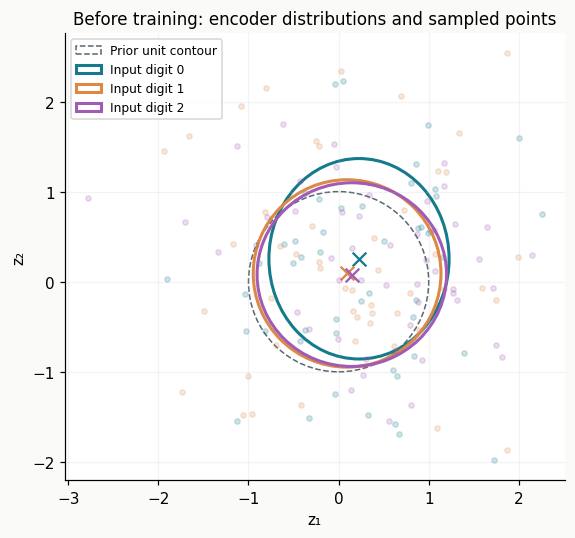

In [8]:
def show_encoded_distributions(model, images, title):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(images)
        std = (0.5 * logvar).exp()
    mu, std = mu.cpu().numpy(), std.cpu().numpy()
    local_rng = np.random.default_rng(SEED + 20)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.add_patch(Ellipse((0, 0), 2, 2, fill=False, ls='--', ec='#596773', label='Prior unit contour'))
    palette = ['#157a8c', '#dd8844', '#a05bb5']
    for k, color in enumerate(palette):
        samples = mu[k] + std[k] * local_rng.standard_normal((50, 2))
        ax.scatter(*samples.T, s=12, alpha=0.2, color=color)
        ax.scatter(*mu[k], marker='x', s=80, color=color)
        ax.add_patch(Ellipse(mu[k], 2 * std[k, 0], 2 * std[k, 1],
                             fill=False, lw=2, ec=color, label=f'Input digit {k}'))
    ax.set(xlabel='z₁', ylabel='z₂', title=title, aspect='equal')
    ax.autoscale_view()
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)
    fig.tight_layout()
    plt.show()

show_encoded_distributions(model, examples[:3], 'Before training: encoder distributions and sampled points')


## Monday · 3. Turn the ELBO into a scalar

### TODO 2 of 3 · Reconstruction, KL, and reduction (about 10–15 min)

Use the exact observation variance in `config['tau_squared']`; it is fixed at
0.1 for this demonstration, not learned. For each image $b$:

$$
R_b=\frac{1}{2\tau^2}\sum_{j=1}^{784}(x_{bj}-m_{\theta,j}(z_b))^2,
\qquad
K_b=\frac12\sum_{i=1}^{2}
\left(\mu_{bi}^2+\exp(\mathrm{logvar}_{bi})-1-\mathrm{logvar}_{bi}\right).
$$

$$
\text{loss}=\frac1B\sum_{b=1}^{B}(R_b+K_b).
$$

Compute vectors `reconstruction_per_image` and `kl_per_image`, both `(B,)`,
then average their sum to a scalar. Return all three so the plots can separate
the competing terms. Reconstruction uses one latent sample per image; KL is analytic.

**Pitfall:** do not average over pixels and then add a summed KL. That silently
changes their relative weight. We omit only the additive Gaussian normalization
constant $C=\frac{784}{2}\log(2\pi\tau^2)$, not the reconstruction scale.
Plots will say **objective (constant omitted)** rather than claim exact NLL.


In [ ]:
def vae_loss(x, decoder_mean, mu, logvar):
    """Return scalar objective and the two per-image loss vectors."""
     # x, decoder_mean: (B, 784) | mu, logvar: (B, 2)
    reconstruction_per_image = (
        (x - decoder_mean)              # (B, 784) -> (B, 784)
        .square()                       # (B, 784) -> (B, 784)
        .sum(dim=1)                     # (B, 784) -> (B)
         / (2 * config['tau_squared']) # (B) -> (B)
    )
    kl_per_coordinate = 0.5 * (mu.square() + (logvar).exp() - 1 - logvar)   # (B, 2) -> (B, 2)
    kl_per_image = kl_per_coordinate.sum(dim=1)                             # (B, 2) -> (B)
    loss = (reconstruction_per_image + kl_per_image).mean()                 # (B) -> scalar
    return loss, reconstruction_per_image, kl_per_image


In [10]:
zeros_x = torch.zeros(3, 784)
zeros_z = torch.zeros(3, 2)
loss, reconstruction, kl = vae_loss(zeros_x, zeros_x, zeros_z, zeros_z)
assert loss.ndim == 0 and reconstruction.shape == kl.shape == (3,)
assert torch.allclose(reconstruction, torch.zeros(3))
assert torch.allclose(kl, torch.zeros(3))

# Means = 1 in two latent coordinates: KL is 1 per image, not 0.5.
loss, _, kl = vae_loss(zeros_x, zeros_x, torch.ones_like(zeros_z), zeros_z)
assert torch.allclose(kl, torch.ones(3)) and torch.allclose(loss, torch.tensor(1.))
# Pixel error = 1 everywhere: check SUM over pixels and the observation scale.
loss, reconstruction, _ = vae_loss(zeros_x, torch.ones_like(zeros_x), zeros_z, zeros_z)
expected = torch.full((3,), 784 / (2 * config['tau_squared']))
assert torch.allclose(reconstruction, expected)
assert torch.allclose(loss, expected.mean())
# General Gaussian KL: compare with PyTorch's distribution implementation.
test_mu = torch.tensor([[0.2, -0.7], [1.1, 0.3]])
test_logvar = torch.tensor([[0.4, -0.8], [-0.2, 0.6]])
_, _, actual_kl = vae_loss(zeros_x[:2], zeros_x[:2], test_mu, test_logvar)
q = torch.distributions.Normal(test_mu, (0.5 * test_logvar).exp())
p = torch.distributions.Normal(torch.zeros_like(test_mu), torch.ones_like(test_mu))
expected_kl = torch.distributions.kl_divergence(q, p).sum(1)
assert torch.allclose(actual_kl, expected_kl, atol=1e-6)
print('Loss checks passed: signs, scales, Gaussian KL, and batch reductions.')


Loss checks passed: signs, scales, Gaussian KL, and batch reductions.


In [11]:
# A disposable model: Tuesday starts fresh, so this check does not alter its run.
with torch.random.fork_rng():
    torch.manual_seed(SEED)
    probe = MinimalVAE().to(device)
    optimizer_probe = torch.optim.Adam(probe.parameters(), lr=config['learning_rate'])
    batch = train_x[:config['batch_size']].to(device)
    decoder_mean, mu, logvar = probe(batch)
    loss, reconstruction, kl = vae_loss(batch, decoder_mean, mu, logvar)
    optimizer_probe.zero_grad()
    loss.backward()
    for name, parameter in probe.named_parameters():
        assert parameter.grad is not None and torch.isfinite(parameter.grad).all(), name
    assert probe.mu_head.weight.grad.abs().sum() > 0
    assert probe.logvar_head.weight.grad.abs().sum() > 0
    assert probe.decoder[0].weight.grad.abs().sum() > 0
    optimizer_probe.step()
    assert all(torch.isfinite(p).all() for p in probe.parameters())
print(f'One step succeeded | reconstruction={reconstruction.mean().item():.2f}'
      f' | KL={kl.mean().item():.2f} | objective={loss.item():.2f}')


One step succeeded | reconstruction=932.96 | KL=0.02 | objective=932.98


## Monday stop · You have a trainable VAE

Stop here if the sampling/loss checks pass and both networks receive finite,
nonzero gradients. You do **not** need attractive reconstructions yet.

Save your working `_solved` notebook. On Tuesday, rerun the preceding cells if
you restarted the kernel, then continue below. No written answer required here.


## Tuesday · 4. Let the model learn

The following cell resets the model, optimizer, and random state before each
run. It trains for the configured five epochs and prints one line per epoch.
There is no hidden checkpoint to load or resume.

The held-out metric uses fixed base-noise draws across epochs, giving a more
comparable (still Monte Carlo) estimate. Neither these examples nor their labels
participate in gradient updates. Training metrics average the minibatch losses
encountered during an epoch; held-out metrics evaluate the model at epoch end.

**Read the two curves separately.** KL need not decrease during learning:
encoding useful information may increase KL while reducing reconstruction cost.
Low KL alone does not establish that the VAE works well.


In [12]:
torch.manual_seed(SEED)
model = MinimalVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
train_loader = make_train_loader()
eval_epsilon = torch.randn((len(test_x), 2), generator=torch.Generator().manual_seed(SEED + 5))

@torch.no_grad()
def evaluate(model):
    model.eval()
    totals = np.zeros(2)
    for start in range(0, len(test_x), config['batch_size']):
        x = test_x[start:start + config['batch_size']].to(device)
        eps = eval_epsilon[start:start + len(x)].to(device)
        mu, logvar = model.encode(x)
        mean = model.decode(reparameterize(mu, logvar, eps))
        _, reconstruction, kl = vae_loss(x, mean, mu, logvar)
        totals += [reconstruction.sum().item(), kl.sum().item()]
    return totals / len(test_x)

with torch.no_grad():
    initial_means = model.decode(model.encode(examples.to(device))[0]).cpu().clone()
initial_metrics = evaluate(model)
history = []
started = time.perf_counter()
for epoch in range(1, config['epochs'] + 1):
    model.train()
    totals = np.zeros(2)
    for (x,) in train_loader:
        x = x.to(device)
        mean, mu, logvar = model(x)
        loss, reconstruction, kl = vae_loss(x, mean, mu, logvar)
        assert torch.isfinite(loss), 'Non-finite loss: check TODO 1 and TODO 2 before tuning anything.'
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        totals += [reconstruction.detach().sum().item(), kl.detach().sum().item()]
    train_metrics = totals / len(train_x)
    heldout = evaluate(model)
    history.append([*train_metrics, *heldout])
    print(f'Epoch {epoch}/{config["epochs"]} | train R={train_metrics[0]:.2f}, KL={train_metrics[1]:.2f}'
          f' | held-out R={heldout[0]:.2f}, KL={heldout[1]:.2f}')
history = np.asarray(history)
assert history.shape == (config['epochs'], 4) and np.isfinite(history).all()
assert (history[:, [1, 3]] >= -1e-5).all()
print(f'Finished in {time.perf_counter() - started:.1f}s; initial held-out objective={initial_metrics.sum():.2f},'
      f' final={history[-1, 2:].sum():.2f} (Gaussian constant omitted).')


Epoch 1/5 | train R=369.94, KL=14.87 | held-out R=267.43, KL=10.85
Epoch 2/5 | train R=245.59, KL=10.55 | held-out R=236.95, KL=9.94
Epoch 3/5 | train R=229.76, KL=8.76 | held-out R=225.80, KL=8.71
Epoch 4/5 | train R=222.18, KL=7.66 | held-out R=219.49, KL=8.00
Epoch 5/5 | train R=217.20, KL=7.29 | held-out R=214.83, KL=7.71
Finished in 0.5s; initial held-out objective=930.25, final=222.54 (Gaussian constant omitted).


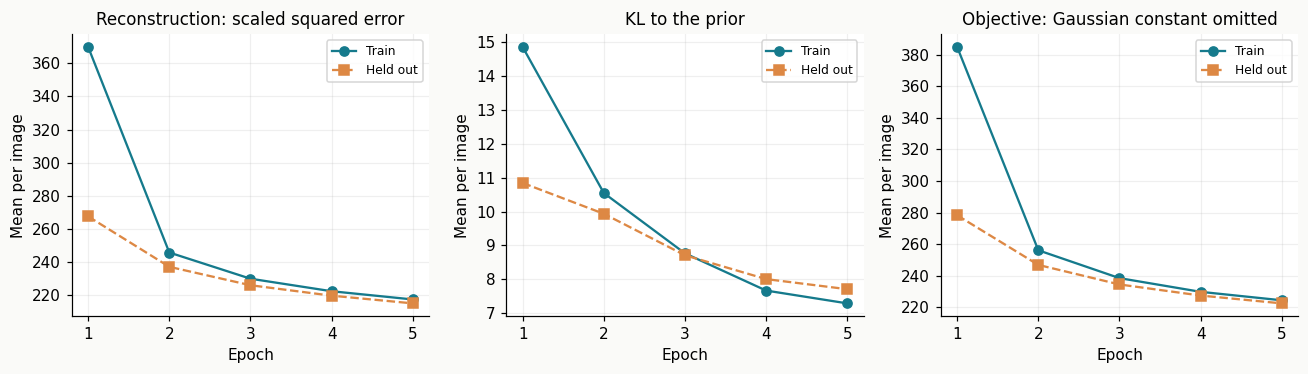

In [13]:
epochs = np.arange(1, len(history) + 1)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
series = [(history[:, 0], history[:, 2], 'Reconstruction: scaled squared error'),
          (history[:, 1], history[:, 3], 'KL to the prior'),
          (history[:, :2].sum(1), history[:, 2:].sum(1), 'Objective: Gaussian constant omitted')]
for ax, (train, heldout, title) in zip(axes, series):
    ax.plot(epochs, train, 'o-', color=COLORS['encoder'], label='Train')
    ax.plot(epochs, heldout, 's--', color=COLORS['decoder'], label='Held out')
    ax.set(title=title, xlabel='Epoch', ylabel='Mean per image', xticks=epochs)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Tuesday · 5. What did encoding and decoding preserve?

Each column below follows the **same held-out input**. For a stable visual
comparison, rows 2–3 decode the encoder mean $z=\mu_\phi(x)$, not a random latent.
This is a visualization convention—not the sampled reconstruction term used
for training, and not the exact posterior-predictive mean.

The bottom row decodes a sampled $z\sim q_\phi(z\mid x)$ to expose latent
uncertainty. All reconstructed images shown here are **decoder means**;
we do not add Gaussian observation noise to these panels.


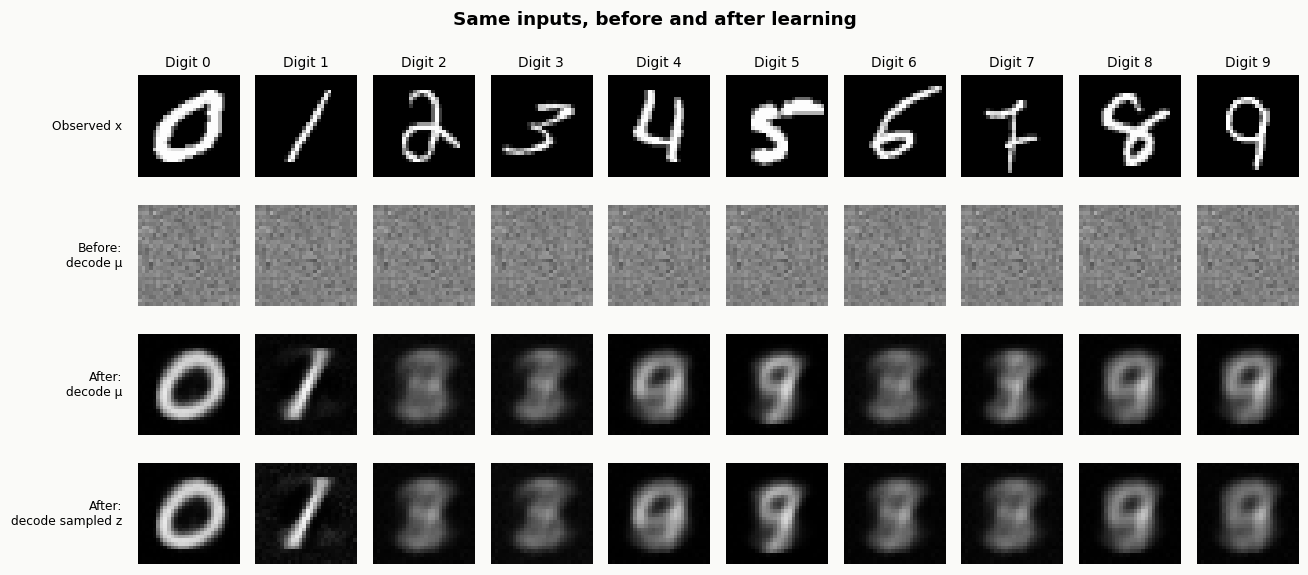

In [16]:
model.eval()
with torch.no_grad(), torch.random.fork_rng():
    torch.manual_seed(SEED + 7)
    mu, logvar = model.encode(examples.to(device))
    final_means = model.decode(mu).cpu()
    sampled_means = model.decode(reparameterize(mu, logvar)).cpu()
assert final_means.shape == sampled_means.shape == examples.shape
fig, axes = plt.subplots(4, 10, figsize=(12, 5.4))
rows = [examples, initial_means, final_means, sampled_means]
row_names = ['Observed x', 'Before:\ndecode μ', 'After:\ndecode μ', 'After:\ndecode sampled z']
for row, images in enumerate(rows):
    for col, ax in enumerate(axes[row]):
        ax.imshow(images[col].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.set(xticks=[], yticks=[])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if col == 0:
            ax.set_ylabel(row_names[row], fontsize=8, rotation=0, ha='right', va='center', labelpad=10)
        if row == 0:
            ax.set_title(f'Digit {col}', fontsize=9)
fig.suptitle('Same inputs, before and after learning', fontweight='bold')
fig.tight_layout()
plt.show()


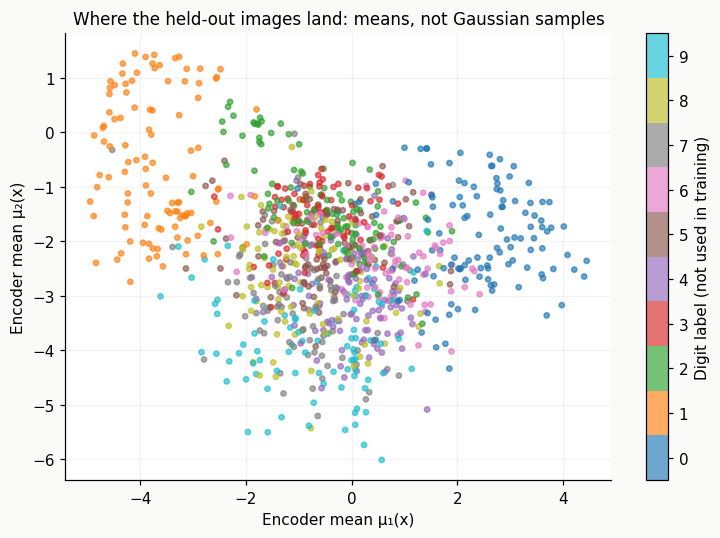

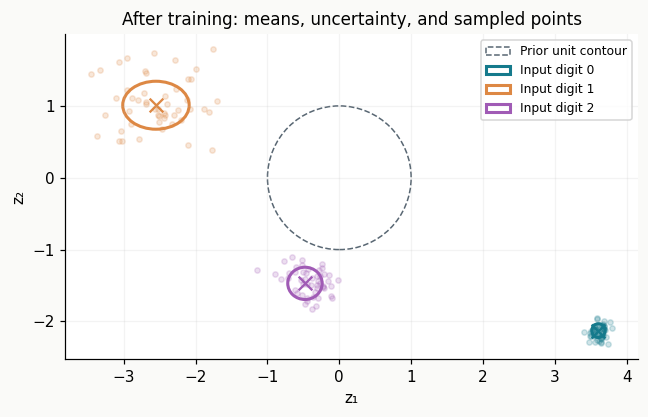

In [17]:
with torch.no_grad():
    all_mu, all_logvar = model.encode(test_x.to(device))
    all_mu = all_mu.cpu()
assert all_mu.shape == (len(test_x), 2) and torch.isfinite(all_mu).all()
fig, ax = plt.subplots(figsize=(7, 5))
points = ax.scatter(all_mu[:, 0], all_mu[:, 1], c=test_y, cmap='tab10',
                    vmin=-0.5, vmax=9.5, s=12, alpha=0.65)
fig.colorbar(points, ax=ax, ticks=range(10), label='Digit label (not used in training)')
ax.set(xlabel='Encoder mean μ₁(x)', ylabel='Encoder mean μ₂(x)',
       title='Where the held-out images land: means, not Gaussian samples')
ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()
show_encoded_distributions(model, examples[:3], 'After training: means, uncertainty, and sampled points')


Read this as a map of **encoder means**, not a proof that the encoded data follow
the standard normal. Each point actually comes with a conditional distribution.
The prior KL encourages compatibility; it does not guarantee perfect matching,
distinct digit clusters, or a semantic meaning for either axis.


### Generate without an input image

Now remove the encoder from the path: sample $z\sim p(z)$ and decode it.
These are **prior-generated decoder means**, not reconstructions of selected
inputs and not full Gaussian observation samples.

A tiny two-dimensional model trained briefly can produce ambiguous digits and
blurry transitions. Assess what the model learned; do not start tuning until
you have finished the three observations at the end.


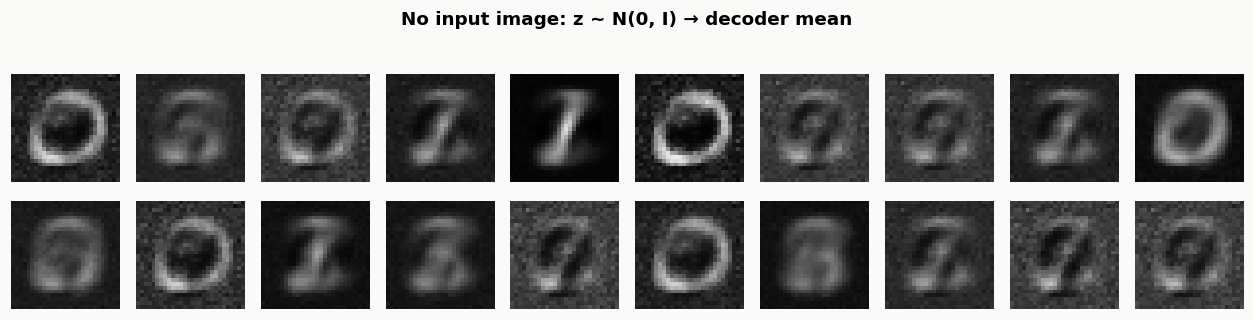

In [18]:
prior_z = torch.randn((20, 2), generator=torch.Generator().manual_seed(SEED + 8)).to(device)
with torch.no_grad():
    generated_means = model.decode(prior_z).cpu()
assert generated_means.shape == (20, 784) and torch.isfinite(generated_means).all()
image_grid(generated_means, rows=2, cols=10, title='No input image: z ~ N(0, I) → decoder mean')


## Tuesday · 6. Move through the learned space

### TODO 3 of 3 · Change one coordinate, hold the other fixed (about 5–10 min)

Start from the encoded mean of one held-out image. Create nine copies of that
point, then replace **only** the selected column with the supplied values.
Return a tensor of shape `(9, 2)`. The plotter handles the rest.

This is a controlled intervention on a latent coordinate, not another random
sample. Compare both axes: they need not correspond neatly to thickness, slant,
or digit identity. Points far from commonly encoded regions may decode poorly.


In [19]:
def traversal_points(anchor: torch.Tensor, coordinate: int, values: torch.Tensor) -> torch.Tensor:
    """Vary one latent coordinate while keeping the other at the anchor."""
    assert anchor.shape == (2,) and coordinate in (0, 1)
    assert values.ndim == 1
    # Repeat the anchor for each value in values
    repeated_anchor = anchor.unsqueeze(0).repeat(len(values), 1)
    # Replace the selected coordinate with the values
    repeated_anchor[:, coordinate] = values
    return repeated_anchor


In [20]:
anchor_check = torch.tensor([0.3, -0.7])
values_check = torch.linspace(-2, 2, 9)
for coordinate in (0, 1):
    points = traversal_points(anchor_check, coordinate, values_check)
    assert points.shape == (9, 2)
    assert torch.allclose(points[:, coordinate], values_check)
    assert torch.allclose(points[:, 1 - coordinate], anchor_check[1 - coordinate].expand(9))
assert torch.equal(anchor_check, torch.tensor([0.3, -0.7])), 'Do not mutate the anchor.'
print('Traversal checks passed: only the chosen coordinate changes.')


Traversal checks passed: only the chosen coordinate changes.


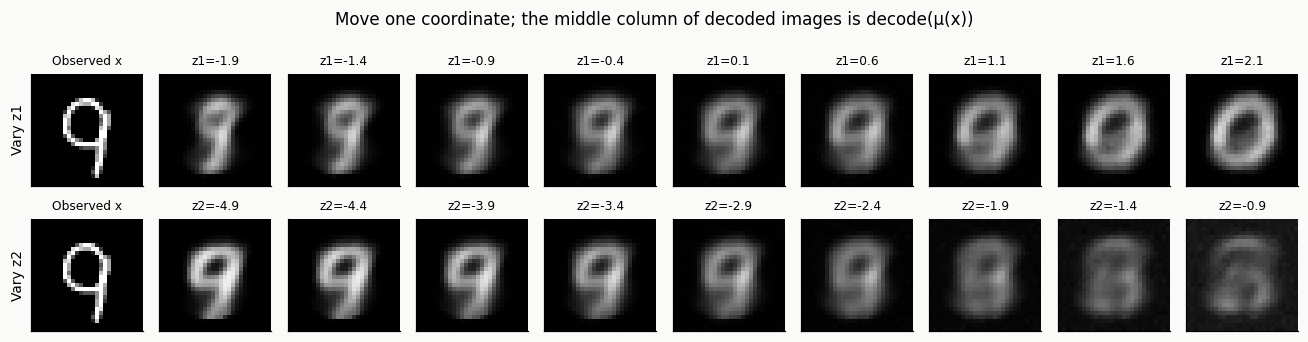

In [21]:
anchor_digit = 9  # A display choice, not a training label.
anchor = model.encode(examples[anchor_digit:anchor_digit + 1].to(device))[0][0].detach()
fig, axes = plt.subplots(2, 10, figsize=(12, 3.3))
for coordinate in (0, 1):
    values = anchor[coordinate] + torch.linspace(-2, 2, 9, device=device)
    points = traversal_points(anchor, coordinate, values)
    with torch.no_grad():
        images = model.decode(points).cpu()
    axes[coordinate, 0].imshow(examples[anchor_digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[coordinate, 0].set_title('Observed x', fontsize=8)
    for k, ax in enumerate(axes[coordinate, 1:]):
        ax.imshow(images[k].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'z{coordinate + 1}={values[k].item():.1f}', fontsize=8)
    for ax in axes[coordinate]:
        ax.set(xticks=[], yticks=[])
    axes[coordinate, 0].set_ylabel(f'Vary z{coordinate + 1}', fontsize=9)
fig.suptitle('Move one coordinate; the middle column of decoded images is decode(μ(x))', fontsize=11)
fig.tight_layout()
plt.show()


## Tuesday stop · Three observations, not another derivation

Write **one or two sentences per prompt**, then stop:

1. **Loss:** Did reconstruction improve? What happened to KL, and why is
   decreasing KL not the sole objective?
2. **Compression:** Identify one feature preserved in a held-out reconstruction
   and one lost or blurred. What limitation does a two-dimensional bottleneck impose?
3. **Generation:** How does reconstructing an input differ from generating from
   the prior? Describe one visible change in your traversal without assuming
   the coordinate has a universal semantic meaning.

**Done means:** your three implementations pass their checks; the short run
finishes with finite losses; you inspect curves, reconstructions, prior means,
and traversals; you write the three observations. Perfect digits, separated
clusters, and monotonically decreasing curves are not requirements.

The separate one-page `w11_why_latent_diffusion.md` wrap-up is still pending.
This notebook demonstrates compression and decoding; it does not train a
diffusion model or reproduce the autoencoder used in a production latent-diffusion system.


### Your observations

1. **Loss:** Reconstruction improved visually and numerically: held-out reconstruction loss decreased from 267.43 to 214.83 between epochs 1 and 5, while KL decreased from 10.85 to 7.71. Minimizing KL alone is insufficient: the objective also rewards reconstructing the input accurately, while KL encourages the approximate posterior $(q_\phi(z\mid x))$ to remain compatible with the standard-normal prior.

2. **Compression:** Among the displayed examples, zero and one are reconstructed most clearly. The zero’s closed loop is preserved, while the two loses its distinctive lower shape and becomes ambiguous, resembling a three. Compressing each image into two latent coordinates limits the detail this model retains, although the small network, brief training, and loss tradeoff also contribute.

3. **Generation and traversal:** Reconstruction conditions the latent distribution on an input image; this notebook’s deterministic comparison decodes its encoder mean. Generation instead samples $(z\sim\mathcal N(0,I))$ without an input image, potentially reaching regions less well represented during training. In my traversal, increasing $(z_2)$ while holding $(z_1)$ fixed gradually turns the reconstructed nine into a less recognizable, blob-like shape.

### Optional later · See the Gaussian observation noise (skip this week if tired)

One extra comparison, with no retraining: for a fixed $z$, display the mean
$m_\theta(z)$ beside an observation $m_\theta(z)+\tau\eta$,
$\eta\sim\mathcal N(0,I_{784})$. This separates observation noise from encoder
sampling noise. Values outside $[0,1]$ are possible; clipping for display changes
the displayed sample, not the underlying Gaussian model.

No implementation is required for completion. Keep the first pass bounded.


tau = 0.316 | 38.5% of sampled pixels fall outside [0, 1] (clipped for display only)


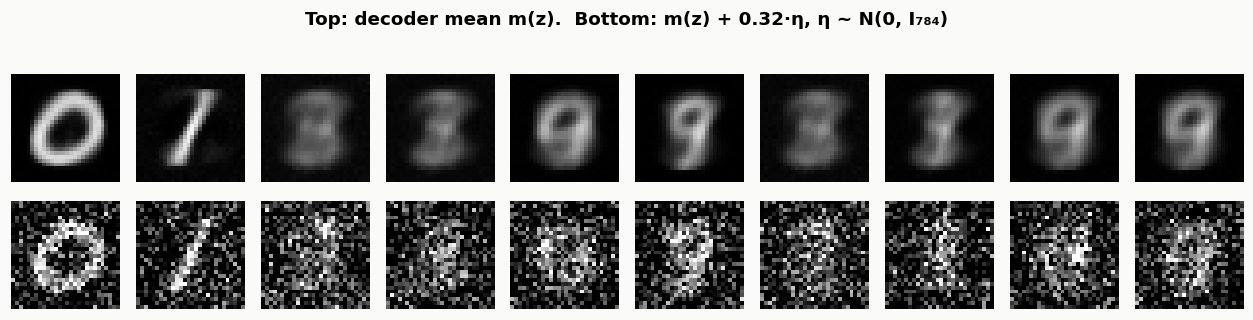

In [22]:
# Fixed z: the encoder mean of the ten held-out examples, so the means below
# match the "After: decode μ" row exactly. Only observation noise is added here.
tau = config['tau_squared'] ** 0.5
model.eval()
with torch.no_grad(), torch.random.fork_rng():
    torch.manual_seed(SEED + 9)
    mu, _ = model.encode(examples.to(device))
    means = model.decode(mu).cpu()
    eta = torch.randn_like(means)
    observations = means + tau * eta

assert means.shape == observations.shape == (10, 784)
outside = ((observations < 0) | (observations > 1)).float().mean().item()
print(f'tau = {tau:.3f} | {outside:.1%} of sampled pixels fall outside [0, 1]'
      ' (clipped for display only)')

# Row 1: decoder means. Row 2: one Gaussian observation sample each.
image_grid(torch.cat([means, observations.clamp(0, 1)]), rows=2, cols=10,
           title=f'Top: decoder mean m(z).  Bottom: m(z) + {tau:.2f}·η, η ~ N(0, I₇₈₄)')